In [17]:
import pandas as pd
import torch
import os
import pickle

## Dataset

In [18]:
meta_data = pd.read_csv(os.path.join("datasets", "Waterbirds", "metadata.csv"))

meta_data.head(10)

,img_id,img_filename,y,split,place,place_filename
0,1,001.Black_footed_Albatross/Black_Footed_Albatr...,1,2,1,/o/ocean/00002178.jpg
1,2,001.Black_footed_Albatross/Black_Footed_Albatr...,1,0,1,/l/lake/natural/00000065.jpg
2,3,001.Black_footed_Albatross/Black_Footed_Albatr...,1,2,0,/b/bamboo_forest/00000131.jpg
3,4,001.Black_footed_Albatross/Black_Footed_Albatr...,1,0,1,/o/ocean/00001268.jpg
4,5,001.Black_footed_Albatross/Black_Footed_Albatr...,1,0,1,/o/ocean/00003147.jpg
5,6,001.Black_footed_Albatross/Black_Footed_Albatr...,1,2,1,/l/lake/natural/00002698.jpg
6,7,001.Black_footed_Albatross/Black_Footed_Albatr...,1,0,1,/o/ocean/00003917.jpg
7,8,001.Black_footed_Albatross/Black_Footed_Albatr...,1,1,1,/o/ocean/00001505.jpg
8,9,001.Black_footed_Albatross/Black_Footed_Albatr...,1,0,1,/l/lake/natural/00000560.jpg
9,10,001.Black_footed_Albatross/Black_Footed_Albatr...,1,2,1,/o/ocean/00002073.jpg


In [19]:
# Count how many images are in each split
split_counts = meta_data['split'].value_counts()
print("Number of images in each split:")
print(split_counts)

Number of images in each split:
split
2    5794
0    4795
1    1199
Name: count, dtype: int64


In [20]:
# Count how many samples of each place-y combinations are in each split
SPLIT_NAMES = {0: "train", 1: "val", 2: "test"}
Y_NAMES = {0: "landbird", 1: "waterbird"}
PLACE_NAMES = {0: "land bg", 1: "water bg"}

group_counts = (
    meta_data
    .assign(
        split_name=meta_data["split"].map(SPLIT_NAMES),
        bird=meta_data["y"].map(Y_NAMES),
        background=meta_data["place"].map(PLACE_NAMES),
    )
    .groupby(["split_name", "bird", "background"], observed=True)
    .size()
    .rename("n")
    .reset_index()
)

# Wide view: one row per (split, bird), one column per background.
table = group_counts.pivot_table(
    index=["split_name", "bird"], columns="background", values="n", fill_value=0
).reindex(["train", "val", "test"], level="split_name")
table["total"] = table.sum(axis=1)
print("Counts per (split, bird, background):")
display(table)

# Same thing as within-split percentages, which is where the spurious
# correlation shows up: train is ~95% majority-group, val/test are balanced.
pct = table.drop(columns="total").div(
    table.groupby(level="split_name", observed=True)["total"].transform("sum"), axis=0
) * 100
print("\nShare of each split (%):")
display(pct.round(1))


Counts per (split, bird, background):


background            land bg  water bg   total
split_name bird                                
train      landbird    3498.0     184.0  3682.0
           waterbird     56.0    1057.0  1113.0
val        landbird     467.0     466.0   933.0
           waterbird    133.0     133.0   266.0
test       landbird    2255.0    2255.0  4510.0
           waterbird    642.0     642.0  1284.0


Share of each split (%):


background            land bg  water bg
split_name bird                        
train      landbird      73.0       3.8
           waterbird      1.2      22.0
val        landbird      38.9      38.9
           waterbird     11.1      11.1
test       landbird      38.9      38.9
           waterbird     11.1      11.1

In [21]:
import pandas as pd

meta_data = pd.read_csv(os.path.join("datasets", "Waterbirds", "metadata.csv"))

# Extract folder, e.g. "001.Black_footed_Albatross"
cub_class_name = meta_data["img_filename"].str.split("/").str[0]


# Extract original CUB class number: 1 ... 200
meta_data["cub_class"] = (
    cub_class_name
    .str.split(".")
    .str[0]
    .astype(int) - 1
)

meta_data.head(100)

,img_id,img_filename,y,split,place,place_filename,cub_class
0,1,001.Black_footed_Albatross/Black_Footed_Albatr...,1,2,1,/o/ocean/00002178.jpg,0
1,2,001.Black_footed_Albatross/Black_Footed_Albatr...,1,0,1,/l/lake/natural/00000065.jpg,0
2,3,001.Black_footed_Albatross/Black_Footed_Albatr...,1,2,0,/b/bamboo_forest/00000131.jpg,0
3,4,001.Black_footed_Albatross/Black_Footed_Albatr...,1,0,1,/o/ocean/00001268.jpg,0
4,5,001.Black_footed_Albatross/Black_Footed_Albatr...,1,0,1,/o/ocean/00003147.jpg,0
...,...,...,...,...,...,...,...
95,96,002.Laysan_Albatross/Laysan_Albatross_0076_671...,1,0,1,/l/lake/natural/00004400.jpg,1
96,97,002.Laysan_Albatross/Laysan_Albatross_0096_673...,1,0,1,/o/ocean/00004001.jpg,1
97,98,002.Laysan_Albatross/Laysan_Albatross_0064_674...,1,2,0,/b/bamboo_forest/00004152.jpg,1
98,99,002.Laysan_Albatross/Laysan_Albatross_0039_924...,1,1,0,/b/bamboo_forest/00001446.jpg,1


### Mateo CUB concepts

In [22]:
ATTRIBUTES_IDX_USED = [1, 4, 6, 7, 10, 14, 15, 20, 21, 23, 25, 29, 30, 35, 36, 38, 40, 44, 45, 50, 51, 53, 54, 56, 57, 59, 63, 64, 69, 70, 72, 75, 80, 84, 90, 91, \
    93, 99, 101, 106, 110, 111, 116, 117, 119, 125, 126, 131, 132, 134, 145, 149, 151, 152, 153, 157, 158, 163, 164, 168, 172, 178, 179, 181, \
    183, 187, 188, 193, 194, 196, 198, 202, 203, 208, 209, 211, 212, 213, 218, 220, 221, 225, 235, 236, 238, 239, 240, 242, 243, 244, 249, 253, \
    254, 259, 260, 262, 268, 274, 277, 283, 289, 292, 293, 294, 298, 299, 304, 305, 308, 309, 310, 311]

with open(os.path.join("datasets", "CUB", "CUB_200_2011", "attributes.txt"), 'r') as f:
    all_attributes_orig_idx = {}
    
    lines = f.readlines()
    for line in lines:
        idx, attr_name = line.strip().split(" ")
        #attr_group, attr_name = attr_name.split("::")  
        # 0-based indexing
        all_attributes_orig_idx[int(idx) - 1] = attr_name
  
# Map between 112 concept idx and attribute name      
sample_112_concepts_map = {new_idx: all_attributes_orig_idx[orig_idx] for new_idx, orig_idx in enumerate(ATTRIBUTES_IDX_USED)}
attr_groups__112_concepts = list(set(attr_name.split("::")[0] for attr_name in sample_112_concepts_map.values()))

print(sample_112_concepts_map)
print(attr_groups__112_concepts)
print(len(attr_groups__112_concepts))


{0: 'has_bill_shape::dagger', 1: 'has_bill_shape::hooked_seabird', 2: 'has_bill_shape::all-purpose', 3: 'has_bill_shape::cone', 4: 'has_wing_color::brown', 5: 'has_wing_color::grey', 6: 'has_wing_color::yellow', 7: 'has_wing_color::black', 8: 'has_wing_color::white', 9: 'has_wing_color::buff', 10: 'has_upperparts_color::brown', 11: 'has_upperparts_color::grey', 12: 'has_upperparts_color::yellow', 13: 'has_upperparts_color::black', 14: 'has_upperparts_color::white', 15: 'has_upperparts_color::buff', 16: 'has_underparts_color::brown', 17: 'has_underparts_color::grey', 18: 'has_underparts_color::yellow', 19: 'has_underparts_color::black', 20: 'has_underparts_color::white', 21: 'has_underparts_color::buff', 22: 'has_breast_pattern::solid', 23: 'has_breast_pattern::striped', 24: 'has_breast_pattern::multi-colored', 25: 'has_back_color::brown', 26: 'has_back_color::grey', 27: 'has_back_color::yellow', 28: 'has_back_color::black', 29: 'has_back_color::white', 30: 'has_back_color::buff', 31: '

In [23]:
# Read dataset dir from the log file in the experiment path
import ast


info_dataset_path = os.path.join("datasets", "CUB", "incomplete_data", "Mateo_025", "info.txt")


with open(info_dataset_path, 'r') as f:
    lines = f.readlines()

    for line in lines:
        if "New attribute indices mapping: " in line:
            new_attribute_mapping_string = line.split("New attribute indices mapping: ")[1].strip()
            
        if "Removed attribute groups: " in line:
            removed_attribute_groups_string = line.split("Removed attribute groups: ")[1].strip()
            

# Original has 112 attributes, but we only use a subset of them
new_attribute_mapping = ast.literal_eval(new_attribute_mapping_string)

# Removed groups list
removed_attribute_groups = ast.literal_eval(removed_attribute_groups_string)
    

        
        
concept_names_new_idx_map = {}
for orig_idx, new_idx in new_attribute_mapping.items():
    concept_names_new_idx_map[new_idx] = sample_112_concepts_map[orig_idx]


df = pd.DataFrame(list(concept_names_new_idx_map.items()), columns=['New Index', 'Concept Name'])
df.to_csv("delete_afterwards/concept_names_new_idx_map.csv", index=False)
display(df.sort_values(by='New Index').reset_index(drop=True))

# Number of attrbutes removed
print(f"Number of attributes removed: {112 - len(concept_names_new_idx_map.keys())}")





,New Index,Concept Name
0,0,has_bill_shape::dagger
1,1,has_bill_shape::hooked_seabird
2,2,has_bill_shape::all-purpose
3,3,has_bill_shape::cone
4,4,has_head_pattern::eyebrow
5,5,has_head_pattern::plain
6,6,has_breast_color::brown
7,7,has_breast_color::grey
8,8,has_breast_color::yellow
9,9,has_breast_color::black


Number of attributes removed: 90


### Check that the image IDs /  in waterbirds and CUB is the same

In [24]:
cub_img_info_file = os.path.join("datasets", "CUB", "CUB_200_2011", "CUB_200_2011", "images.txt")


with open(cub_img_info_file, "r") as f:
    cub_img_info = f.readlines()
    for i in range(len(cub_img_info)):
            
        cub_image_name = cub_img_info[i].strip().split(" ")[1]
        cub_image_id = int(cub_img_info[i].strip().split(" ")[0])
        # Get the corresponding row in the metadata DataFrame by using img_id
        row = meta_data[meta_data['img_id'] == cub_image_id]
        if i == 0:
            print(f"Checking image ID {cub_image_id} with name {cub_image_name}")
        if not row.empty:
            # Check if the image name matches
            if row.iloc[0]['img_filename'] != cub_image_name:
                raise ValueError(f"Image name mismatch for ID {cub_image_id}: {row.iloc[0]['img_filename']} vs {cub_image_name}")
        else: 
            raise ValueError(f"Image ID {cub_image_id} not found in metadata DataFrame.")
        





Checking image ID 1 with name 001.Black_footed_Albatross/Black_Footed_Albatross_0046_18.jpg


### Waterbirds script

Check that Waterbirds metadata file and CUB pkl files have matching relative image file paths for image IDs 

In [25]:



pkl_dir = os.path.join("datasets", "CUB", "class_attr_data_10")


cub_annotations = {}

for pkl_file in ("train.pkl", "val.pkl", "test.pkl"):
    with open(os.path.join(pkl_dir, pkl_file), "rb") as f:
        for sample in pickle.load(f):
            cub_annotations[sample["id"]] = {
                "class_label": sample["class_label"],
                "attribute_label": sample["attribute_label"],
                "rel_path": "/".join(sample["img_path"].split("/")[-2:])
            }
            
            

for img_id, info in cub_annotations.items():
    # Get the corresponding row in the metadata DataFrame by using img_id
    row = meta_data[meta_data['img_id'] == img_id]
    if not row.empty:
        # Check if the image name matches
        if row.iloc[0]['img_filename'] != info["rel_path"]:
            raise ValueError(f"Image name mismatch for ID {img_id}: {row.iloc[0]['img_filename']} vs {info['rel_path']}")
    else: 
        raise ValueError(f"Image ID {img_id} not found in metadata DataFrame.")

/var/folders/wb/9whmmh7s5bvf174ppr2jwprr0000gn/T/ipykernel_46708/3718808309.py:8: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  for sample in pickle.load(f):


## Analysis

In [26]:
def extract_info_from_intervention_log(model_dir, model_type="scbm", dataset="TravelingBirds", return_c_auroc=False, return_auroc=False, intervention_on_val=False, folder=None):
    experiment_path = os.path.join("experiments", model_type, dataset)
    concepts_intervened_list = []
    y_accuracies_list = []
    c_accuracies_list = []
    y_auroc_list = []
    c_auroc_list = []
    if intervention_on_val and folder is not None:
        raise ValueError("If intervention_on_val is True, folder should be None. The function will automatically look for the validation log.")
    elif intervention_on_val:
        log_txt_path = os.path.join(experiment_path, model_dir, "intervention_log_val.txt")
    elif folder is not None:
        log_txt_path = os.path.join(experiment_path, model_dir, folder, "intervention_log.txt")
    else:
        log_txt_path = os.path.join(experiment_path, model_dir, "intervention_log.txt")
    with open(log_txt_path, "r") as f:
        lines = f.readlines()
        for line in lines:
            if "Intervention on" in line and "y_accuracy" in line and "c_accuracy" in line:
                m = re.search(r"Intervention on (\d+) concepts", line)
                if not m:
                    continue
                concepts_intervened = int(m.group(1))

                y_m = re.search(r"y_accuracy:\s*([0-9.]+)", line)
                c_m = re.search(r"c_accuracy:\s*([0-9.]+)", line)
                y_auroc_m = re.search(r"y_AUROC:\s*([0-9.]+)", line)
                c_auroc_m = re.search(r"c_AUROC:\s*([0-9.]+)", line)

                y_accuracy = float(y_m.group(1)) * 100 if y_m else None
                c_accuracy = float(c_m.group(1)) * 100 if c_m else None
                y_auroc = float(y_auroc_m.group(1)) * 100 if y_auroc_m else None
                c_auroc = float(c_auroc_m.group(1)) * 100 if c_auroc_m else None

                concepts_intervened_list.append(concepts_intervened)
                y_accuracies_list.append(y_accuracy)
                c_accuracies_list.append(c_accuracy)
                y_auroc_list.append(y_auroc)
                c_auroc_list.append(c_auroc)
    if return_auroc:
        return concepts_intervened_list, y_accuracies_list, c_accuracies_list, y_auroc_list, c_auroc_list
    if return_c_auroc:
        return concepts_intervened_list, y_accuracies_list, c_accuracies_list, c_auroc_list
    return concepts_intervened_list, y_accuracies_list, c_accuracies_list

[Waterbirds  200 classes] SCBM                                     23 points  Mateo_025_2026-08-29_18-49-38_47e41
[Waterbirds  200 classes] Hard CBM                                 23 points  Mateo_025_2026-08-30_22-20-04_f7cdb
[Waterbirds  200 classes] Soft CBM                                 23 points  Mateo_025_soft_cbm_2026-08-30_22-23-40_9ad43
[Waterbirds  200 classes] Res-SCBM (20 res)                        23 points  Mateo_025_fixed_residuals_20_2026-08-29_18-49-10_908dc
[Waterbirds  200 classes] Res-SCBM (20 res), L_int_ext w=1         23 points  Mateo_025_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-08-29_18-49-05_25326
[Waterbirds    2 classes] SCBM                                     23 points  Mateo_025_binary_target_2026-08-29_18-49-41_3f498
[Waterbirds    2 classes] Hard CBM                                 23 points  Mateo_025_binary_target_2026-08-31_10-38-22_50373
[Waterbirds    2 classes] Soft CBM                                 23 points  Mateo_025_

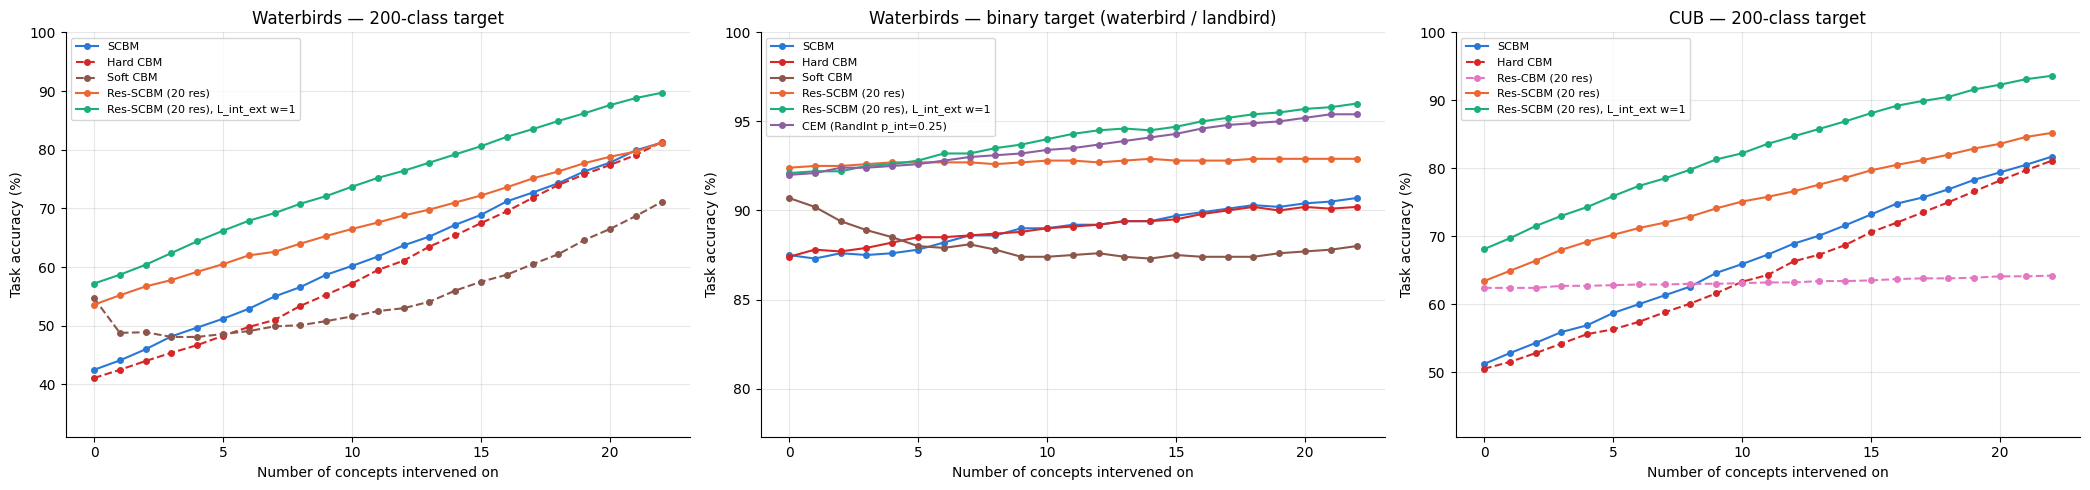

In [27]:
# ---- All intervention curves (CBM + SCBM + Res-SCBM) in one figure ----
import re
import ast
import matplotlib.pyplot as plt

# (label, model_type, run_dir) -- model_type selects the experiments/<model_type>/<dataset>/
# subfolder. Listed explicitly so that adding new runs to experiments/ does not silently
# change this plot; add a line here to include a run.
WATERBIRDS_RUNS = [
    # Only the 20-residual variants are kept: the residual width is not the question here,
    # and the 5/50-residual runs crowd the panels. Their run dirs are in git history.
    # 200-class target
    ("SCBM", "scbm", "Mateo_025_2026-08-29_18-49-38_47e41"),
    ("Hard CBM", "cbm", "Mateo_025_2026-08-30_22-20-04_f7cdb"),
    ("Soft CBM", "cbm", "Mateo_025_soft_cbm_2026-08-30_22-23-40_9ad43"),
    ("Res-SCBM (20 res)", "scbm_residual", "Mateo_025_fixed_residuals_20_2026-08-29_18-49-10_908dc"),
    ("Res-SCBM (20 res), L_int_ext w=1", "scbm_residual", "Mateo_025_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-08-29_18-49-05_25326"),
    # binary target (waterbird / landbird)
    ("SCBM", "scbm", "Mateo_025_binary_target_2026-08-29_18-49-41_3f498"),
    ("Hard CBM", "cbm", "Mateo_025_binary_target_2026-08-31_10-38-22_50373"),
    ("Soft CBM", "cbm", "Mateo_025_soft_cbm_binary_target_2026-08-31_10-38-26_a6936"),
    ("Res-SCBM (20 res)", "scbm_residual", "Mateo_025_fixed_residuals_20_binary_target_2026-08-29_18-49-11_af585"),
    ("Res-SCBM (20 res), L_int_ext w=1", "scbm_residual", "Mateo_025_fixed_emp_perc_residuals_20_binary_target_L_int_extension_loss_weight_1_2026-08-29_18-49-08_c48a7"),
    # CEM (concept_learning="embedding") is registered under model_type "cbm", so it lands in
    # experiments/cbm/Waterbirds/. Caveat: it is the only run here trained on interventions
    # (RandInt, model.p_int=0.25), so its slope with concept count is not a like-for-like
    # comparison against the others.
    ("CEM (RandInt p_int=0.25)", "cbm", "cem_p_int_0.25_Mateo_025_binary_target_2026-09-09_16-14-32_442e2"),
]

# The matching CUB runs (same Mateo_025 incomplete split, same 22 concepts, 200 classes),
# plotted as a third panel so the Waterbirds curves can be read against the plain-CUB
# behaviour of the same model families. Run dirs taken from results_aug.ipynb.
CUB_RUNS = [
    ("SCBM", "scbm", "Mateo_025_2026-08-11_12-42-07_1357b"),
    ("Hard CBM", "cbm", "Mateo_025_2026-08-03_20-58-31_fe8e0"),
    ("Res-CBM (20 res)", "cbm_residual", "Mateo_025_2026-08-06_16-24-27_dd094"),
    ("Res-SCBM (20 res)", "scbm_residual", "Mateo_025_fixed_residuals_20_2026-08-13_16-06-32_a9023"),
    ("Res-SCBM (20 res), L_int_ext w=1", "scbm_residual", "Mateo_025_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-07-31_20-15-47_174e5"),
]

# Dashed for the CBM family, solid for the (S)CBM ones, so the two groups stay
# tellable apart where their colours sit close together. The binary panel is the
# exception -- see BINARY_ALL_SOLID below.
LINESTYLES = {"cbm": "--", "cbm_residual": "--"}

# The binary panel is drawn with every curve solid, telling the models apart by colour
# alone: its curves sit in a narrow band near the top of the range, where a dashed line
# reads as a gap in the curve rather than as a model family.
BINARY_ALL_SOLID = True

# One colour per label, so the same model is the same colour in every panel.
COLORS = {
    "SCBM": "#2a78d6",
    "Hard CBM": "#d62728",
    "Soft CBM": "#8c564b",
    "Res-CBM (20 res)": "#e377c2",
    "Res-SCBM (20 res)": "#eb6834",
    "Res-SCBM (20 res), L_int_ext w=1": "#1baf7a",
    "CEM (RandInt p_int=0.25)": "#8e5ea2",
}


def read_run_config(run_path):
    """First line of log.txt is the full config dict."""
    with open(os.path.join(run_path, "log.txt"), "r") as f:
        return ast.literal_eval(f.readline().strip())


def parse_intervention_log(log_txt_path):
    """Return (xs, rows) with rows[i] a {metric: value} dict for xs[i] concepts intervened.

    Keyed by concept count so that a log containing a partial sweep followed by a
    re-run (as in the residuals_20 L_int_ext run) keeps the *last* value written.
    """
    curve = {}
    with open(log_txt_path, "r") as f:
        for line in f:
            m = re.search(r"Intervention on (\d+) concepts", line)
            if not m or "y_accuracy" not in line:
                continue
            metrics = {
                k: float(v) for k, v in re.findall(r"([A-Za-z_\-]+):\s*([0-9.]+)", line)
            }
            curve[int(m.group(1))] = metrics
    xs = sorted(curve)
    return xs, [curve[x] for x in xs]


def collect_runs(runs, dataset, metric="y_accuracy"):
    collected = []
    for label, model_type, run_dir in runs:
        run_path = os.path.join("experiments", model_type, dataset, run_dir)
        cfg = read_run_config(run_path)
        xs, rows = parse_intervention_log(os.path.join(run_path, "intervention_log.txt"))
        collected.append({
            "label": label,
            "run_dir": run_dir,
            "model_type": model_type,
            "dataset": dataset,
            "num_classes": cfg["data"]["num_classes"],
            "x": xs,
            "y": [r[metric] * 100 for r in rows],
        })
    return collected


metric = "y_accuracy"
runs = (collect_runs(WATERBIRDS_RUNS, "Waterbirds", metric=metric)
        + collect_runs(CUB_RUNS, "CUB", metric=metric))
for r in runs:
    print(f"[{r['dataset']:<11} {r['num_classes']:>3} classes] {r['label']:<40} "
          f"{len(r['x']):>2} points  {r['run_dir']}")

# 2-class (waterbird vs landbird) and 200-class runs live on very different accuracy
# scales, and CUB is a different dataset again, so give each its own panel; every
# curve still sits in one figure.
PANELS = [("Waterbirds", 200), ("Waterbirds", 2), ("CUB", 200)]

fig, axes = plt.subplots(1, len(PANELS), figsize=(7 * len(PANELS), 5), squeeze=False)
for ax, (dataset, num_classes) in zip(axes[0], PANELS):
    group_runs = [r for r in runs if r["dataset"] == dataset and r["num_classes"] == num_classes]
    for r in group_runs:
        ax.plot(
            r["x"], r["y"], marker="o", ms=4,
            color=COLORS.get(r["label"]),
            linestyle=("-" if (BINARY_ALL_SOLID and num_classes == 2)
                       else LINESTYLES.get(r["model_type"], "-")),
            label=r["label"],
        )
    target = "binary target (waterbird / landbird)" if num_classes == 2 else f"{num_classes}-class target"
    ax.set_title(f"{dataset} — {target}")
    ax.set_xlabel("Number of concepts intervened on")
    ax.set_ylabel("Task accuracy (%)")
    # A binary target sits near the top of the range; clipping to [0, 100] would
    # flatten the curves, so pad around the data instead.
    lo = min(min(r["y"]) for r in group_runs)
    ax.set_ylim(max(0, lo - 10), 100)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.show()

## Species to binary label lookup table

`WATERBIRDS_RUNS` mixes two kinds of model, and `y_true` means something different in each: the
**binary** runs predict landbird/waterbird directly (one logit), the **200-way** runs predict the
CUB species. Any table that puts them in the same column has to say which quantity it holds.

`sp2y` is the bridge -- a length-200 lookup, `sp2y[k] = 0 | 1` for species `k`. `.first()` is
exact rather than a majority vote: `y` is a deterministic function of species in Waterbirds
(Sagawa et al. label each CUB species land or water), and no species carries more than one `y`
anywhere in the dataset -- 46 waterbird species against 154 landbird ones. The `.fillna(0)` never
fires on this split, where all 200 species are present; it would only matter for a split that
dropped a species.

**The 200-way prediction is collapsed after the argmax, not marginalized:**

```python
pred      = yp.argmax(1)        # 1. hard decision over 200 species
pred_y    = sp2y[pred]          # 2. that species' land/water label
correct_y = pred_y == y_bin     # 3. compare against the binary ground truth
```

A prediction therefore counts as correct whenever the predicted species falls on the right side of
the land/water divide, even if it is the wrong species -- which is why the same runs read 41-59%
on species accuracy and ~98% ID on the collapsed decision. Two consequences:

- Marginalizing instead (summing probability over the 46 waterbird species against the 154
  landbird ones) would be a slightly *better* binary classifier, since it does not discard the
  runner-up species. The collapsed numbers are a lower bound on what a 200-way model can do on
  the binary task.
- The hard collapse leaves no scalar score, so the AUROC columns further down are `NaN` for every
  200-way run. A marginalized log-odds would fill them in.

Which metric each cell reports:

| Metric | Meaning | Where |
|---|---|---|
| `y_acc`, `overall`, `worst_group`, `gap_*` | The model's **own** target: species accuracy for 200-way, land/water for binary. Not comparable between the two blocks. | the intervention-curve cell and both group figures |
| `y_acc_binary`, `bin ID`, `bin OOD` | The **collapsed** land/water decision, identical to `y_acc` for binary runs. Comparable across both targets. | the ID/OOD table below; computed but not plotted in the group figures |

Because differencing two species accuracies compresses the effect a background can have, the
200-way panels of the group figures show smaller gaps than the binary ones partly for metric
reasons, not only because those models lean on the background less.

In [28]:
md = pd.read_csv(os.path.join("datasets", "Waterbirds", "metadata.csv"))
te = md[md["split"] == 2].reset_index(drop=True)  # loader order == metadata.csv row order
place = te["place"].values
y_bin = te["y"].values
species = (te["img_filename"].str.split("/").str[0].str.split(".").str[0].astype(int) - 1).values
majority = y_bin == place

# species -> landbird/waterbird, for scoring the 200-way models on the binary task
sp2y = pd.Series(y_bin, index=species).groupby(level=0).first()
sp2y = sp2y.reindex(range(200)).fillna(0).astype(int).values
print(f"Species to binary label mapping (first 10): {sp2y[:10]}")
print(len(sp2y), "species in total")

Species to binary label mapping (first 10): [1 1 1 0 1 1 1 1 0 0]
200 species in total


## Majority and minority metrics inference

In [29]:
# ---- ID / OOD test-set metrics from saved y_true / y_pred (no interventions) ----
# ID  = majority group (y == place): the correlation the model saw in 95% of training.
# OOD = minority group (y != place): correlation broken.
# Reads the runs from WATERBIRDS_RUNS above, so this table and the intervention plot
# always describe the same set of models. Runs without a test/ dump are reported as
# skipped rather than silently dropped.
import ast
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import roc_auc_score

md = pd.read_csv(os.path.join("datasets", "Waterbirds", "metadata.csv"))
te = md[md["split"] == 2].reset_index(drop=True)  # loader order == metadata.csv row order
place = te["place"].values
y_bin = te["y"].values
species = (te["img_filename"].str.split("/").str[0].str.split(".").str[0].astype(int) - 1).values
majority = y_bin == place

# species -> landbird/waterbird, for scoring the 200-way models on the binary task
sp2y = pd.Series(y_bin, index=species).groupby(level=0).first()
sp2y = sp2y.reindex(range(200)).fillna(0).astype(int).values

GROUPS = [("landbird / land", 0, 0), ("landbird / water", 0, 1),
          ("waterbird / land", 1, 0), ("waterbird / water", 1, 1)]

rows, skipped = [], []
for label, model_type, run_dir in WATERBIRDS_RUNS:
    run_path = os.path.join("experiments", model_type, "Waterbirds", run_dir)
    test_dir = os.path.join(run_path, "test")
    # SCBM and CBM does not have y_true
    if not os.path.exists(os.path.join(test_dir, "y_true.pt")):
        # Run was trained without data.save_concept_and_residual_channel=True.
        skipped.append((label, model_type, run_dir))
        continue

    cfg = ast.literal_eval(open(os.path.join(run_path, "log.txt")).readline().strip())
    yt = torch.load(os.path.join(test_dir, "y_true.pt"), map_location="cpu").numpy()
    yp = torch.load(os.path.join(test_dir, "y_pred.pt"), map_location="cpu").float().numpy()

    binary = cfg["data"]["num_classes"] == 2
    if binary:
        score = yp.squeeze(-1)          # single logit
        pred = (score > 0).astype(int)
        pred_y = pred                   # already the landbird/waterbird decision
        # Row alignment is the whole basis of the place join: verify, don't assume.
        assert (yt == y_bin).all(), f"{run_dir}: saved rows are not in metadata order"
    else:
        pred = yp.argmax(1)             # log-probs over the 200 species
        pred_y = sp2y[pred]             # induced landbird/waterbird decision
        score = None
        assert (yt == species).all(), f"{run_dir}: saved rows are not in metadata order"

    correct = pred == yt
    row = {
        "target": "binary" if binary else "200-way",
        "model": label,
        "overall": 100 * correct.mean(),
        "ID (y==place)": 100 * correct[majority].mean(),
        "OOD (y!=place)": 100 * correct[~majority].mean(),
    }
    row["gap"] = row["ID (y==place)"] - row["OOD (y!=place)"]
    for group_label, yv, pv in GROUPS:
        row[group_label] = 100 * correct[(y_bin == yv) & (place == pv)].mean()
    row["worst group"] = min(row[g[0]] for g in GROUPS)
    # Landbird/waterbird decision, so the two target types sit on one scale.
    correct_y = pred_y == y_bin
    row["bin ID"] = 100 * correct_y[majority].mean()
    row["bin OOD"] = 100 * correct_y[~majority].mean()
    row["bin AUROC ID"] = 100 * roc_auc_score(y_bin[majority], score[majority]) if binary else np.nan
    row["bin AUROC OOD"] = 100 * roc_auc_score(y_bin[~majority], score[~majority]) if binary else np.nan
    rows.append(row)

id_ood_df = pd.DataFrame(rows).set_index(["target", "model"]).sort_index()

pd.set_option("display.width", 250)
pd.set_option("display.max_columns", 20)
print(f"Waterbirds test set, no interventions "
      f"(n={len(te)}: {majority.sum()} ID / {(~majority).sum()} OOD)\n")
print("--- task accuracy on the model's own target (%) ---")
display(id_ood_df[["overall", "ID (y==place)", "OOD (y!=place)", "gap"]].round(1))
print("\n--- per (bird / background) group accuracy on own target (%) ---")
display(id_ood_df[[g[0] for g in GROUPS] + ["worst group"]].round(1))
print("\n--- landbird/waterbird decision, common scale across both targets (binary target)(%) ---")
display(id_ood_df[["bin ID", "bin OOD", "bin AUROC ID", "bin AUROC OOD"]].round(1))

if skipped:
    print(f"\nNo test/ dump, skipped ({len(skipped)}):")
    for label, model_type, run_dir in skipped:
        print(f"  {model_type:<14} {label:<34} {run_dir}")

Waterbirds test set, no interventions (n=5794: 2897 ID / 2897 OOD)

--- task accuracy on the model's own target (%) ---


overall  ID (y==place)  OOD (y!=place)   gap
target  model                                                                         
200-way Res-SCBM (20 res)                    53.3           56.0            50.6   5.4
        Res-SCBM (20 res), L_int_ext w=1     57.2           61.1            53.3   7.8
        SCBM                                 42.2           45.4            39.0   6.5
binary  CEM (RandInt p_int=0.25)             92.0           98.6            85.5  13.1
        Res-SCBM (20 res)                    92.4           98.4            86.5  11.9
        Res-SCBM (20 res), L_int_ext w=1     92.1           98.4            85.8  12.6
        SCBM                                 87.5           91.9            83.1   8.8


--- per (bird / background) group accuracy on own target (%) ---


landbird / land  landbird / water  waterbird / land  waterbird / water  worst group
target  model                                                                                                                
200-way Res-SCBM (20 res)                            58.6              53.3              41.3               46.7         41.3
        Res-SCBM (20 res), L_int_ext w=1             64.5              56.0              43.8               48.9         43.8
        SCBM                                         48.4              40.8              32.4               34.9         32.4
binary  CEM (RandInt p_int=0.25)                     99.2              89.5              71.2               96.3         71.2
        Res-SCBM (20 res)                            99.7              92.2              66.2               93.6         66.2
        Res-SCBM (20 res), L_int_ext w=1             99.8              92.3              63.1               93.5         63.1
        SCBM                                         97.9              92.9              48.3               70.7         48.3


--- landbird/waterbird decision, common scale across both targets (binary target)(%) ---


bin ID  bin OOD  bin AUROC ID  bin AUROC OOD
target  model                                                                         
200-way Res-SCBM (20 res)                   98.2     86.5           NaN            NaN
        Res-SCBM (20 res), L_int_ext w=1    98.4     86.2           NaN            NaN
        SCBM                                96.7     84.8           NaN            NaN
binary  CEM (RandInt p_int=0.25)            98.6     85.5          99.9           89.5
        Res-SCBM (20 res)                   98.4     86.5          99.8           89.5
        Res-SCBM (20 res), L_int_ext w=1    98.4     85.8          99.9           88.1
        SCBM                                91.9     83.1          96.6           86.6


No test/ dump, skipped (4):
  cbm            Hard CBM                           Mateo_025_2026-08-30_22-20-04_f7cdb
  cbm            Soft CBM                           Mateo_025_soft_cbm_2026-08-30_22-23-40_9ad43
  cbm            Hard CBM                           Mateo_025_binary_target_2026-08-31_10-38-22_50373
  cbm            Soft CBM                           Mateo_025_soft_cbm_binary_target_2026-08-31_10-38-26_a6936


## Group-wise intervention curves (bird x background)

The average intervention curve is the same for a head that reads the background and a head
that reads the bird. Splitting the test set into its four (bird, background) cells is what
tells them apart: worst-group accuracy, and the majority-minority gap.

Requires the per-sample dumps: `python scripts/rerun_interventions_with_preds.py`.

In [30]:
# ---- Per-(bird, background) intervention curves ----
# The curve in intervention_log.txt is an average over the test split, and on Waterbirds the
# average is what hides the question: a head reading the background and a head reading the bird
# can sit at the same accuracy. The four cells separate them -- a background reader gets the two
# agreeing cells nearly free and is actively pointed at the wrong class in the two disagreeing
# ones, so it shows a large gap and a low, flat worst-group curve; a concept-driven head shows a
# small gap and a worst-group curve that rises as concepts are handed over.
#
# Needs the per-sample dumps written by inference.save_intervention_predictions=True, i.e.
#   python scripts/rerun_interventions_with_preds.py
# Runs without one are listed rather than silently dropped.
import textwrap
from pathlib import Path

import numpy as np

MD_BY_ID = pd.read_csv(os.path.join("datasets", "Waterbirds", "metadata.csv")).set_index("img_id")
GROUPS4 = [("landbird / land", 0, 0), ("landbird / water", 0, 1),
           ("waterbird / land", 1, 0), ("waterbird / water", 1, 1)]
# The cells where the background agrees with the label -- the 95% correlation seen in training.
MAJORITY_GROUPS = {"landbird / land", "waterbird / water"}
# The dump is keyed by <strategy>_<policy>, so a run swept under more than one strategy keeps both.
# Curves measured with different strategies are not comparable, so pick one and say which:
# emp_perc is the strategy every family supports. Hard CBMs are the exception -- define_strategy
# pins concept_learning=hard to HardCBMStrategy before it reads the strategy name -- so they land
# in hard_random/ and fall through to the single-combination case below.
PREFERRED_COMBO = "emp_perc_random"


def load_group_curve(label, model_type, run_dir, dataset="Waterbirds", experiment_dir="experiments",
                     combo=None):
    """Per-(bird, background) accuracy at every point of one run's intervention curve.

    Joins the dump to metadata.csv on the CUB image id recorded in img_ids.txt, so nothing
    depends on the loader order happening to match the csv; y_true is then a check on that join
    rather than the join itself.
    """
    run_path = Path(experiment_dir) / model_type / dataset / run_dir
    combos = sorted(p for p in (run_path / "intervention_preds").glob("*") if p.is_dir())
    if not combos:
        return None
    wanted = combo or PREFERRED_COMBO
    match = [p for p in combos if p.name == wanted]
    if match:
        d = match[0]
    elif len(combos) == 1:
        d = combos[0]
    else:
        raise ValueError(
            f"{run_dir}: no {wanted}/ dump and {len(combos)} strategies to choose between "
            f"({', '.join(p.name for p in combos)}). Pass combo= to pick one."
        )

    ids = np.loadtxt(d / "img_ids.txt", dtype=int)
    rows = MD_BY_ID.loc[ids]
    # y is the binary landbird/waterbird label, place is the background, and species is the CUB class.
    place, y_bin = rows["place"].to_numpy(), rows["y"].to_numpy()
    # The CUB class idx
    species = (rows["img_filename"].str.split("/").str[0].str.split(".").str[0].astype(int) - 1).to_numpy()
    # species -> landbird/waterbird, to score the 200-way models on the binary task too.
    sp2y = (pd.Series(y_bin, index=species).groupby(level=0).first()
            .reindex(range(200)).ffill().bfill().astype(int).to_numpy())

    y_true = torch.load(d / "y_true.pt", map_location="cpu").numpy()
    c_true = torch.load(d / "c_true.pt", map_location="cpu").numpy().astype(bool)
    binary = read_run_config(run_path)["data"]["num_classes"] == 2
    assert (y_true == (y_bin if binary else species)).all(), f"{run_dir}: id join disagrees with y_true"

    recs = []
    for f in sorted(d.glob("step_*.pt")):
        n = int(f.stem.split("_")[1])
        blob = torch.load(f, map_location="cpu")
        logits = blob["y_pred_logits"].float().numpy()
        c_pred = blob["c_pred_probs"].float().numpy() > 0.5
        # Binary runs emit a single logit; the 200-way ones a score per species.
        pred = (logits.reshape(len(y_true), -1)[:, 0] > 0).astype(int) if binary else logits.argmax(1)
        correct = pred == y_true
        correct_bin = (pred if binary else sp2y[pred]) == y_bin  # induced landbird/waterbird call
        c_correct = (c_pred == c_true).mean(1)
        for group, yv, pv in GROUPS4:
            m = (y_bin == yv) & (place == pv)
            recs.append({
                "label": label, "model_type": model_type, "run_dir": run_dir,
                "target": "binary" if binary else "200-way", "combo": d.name, "n_intervened": n,
                "group": group, "majority": group in MAJORITY_GROUPS, "size": int(m.sum()),
                "y_acc": 100 * correct[m].mean(),
                "y_acc_binary": 100 * correct_bin[m].mean(),
                "c_acc": 100 * c_correct[m].mean(),
            })
    return pd.DataFrame(recs)


def summarize_group_curve(curve, metric="y_acc"):
    """Collapse the four cells to the numbers the hypotheses differ on, per intervention count.

    Both gap definitions are reported because they disagree here: the minority half of the test
    set is 78% landbird/water, the cell that is *not* in trouble, so the sample-weighted gap is
    the milder of the two. worst_group is the number neither average can bound.
    """
    out = []
    for n, g in curve.groupby("n_intervened"):
        maj, mino = g[g["majority"]], g[~g["majority"]]
        out.append({
            "label": g["label"].iloc[0], "target": g["target"].iloc[0],
            "model_type": g["model_type"].iloc[0], "n_intervened": n,
            "overall": float((g[metric] * g["size"]).sum() / g["size"].sum()),
            "worst_group": float(g[metric].min()),
            "gap_weighted": float((maj[metric] * maj["size"]).sum() / maj["size"].sum()
                                  - (mino[metric] * mino["size"]).sum() / mino["size"].sum()),
            "gap_unweighted": float(maj[metric].mean() - mino[metric].mean()),
        })
    return pd.DataFrame(out)


group_curves, no_dump = [], []
for label, model_type, run_dir in WATERBIRDS_RUNS:
    curve = load_group_curve(label, model_type, run_dir)
    if curve is None:
        no_dump.append((label, model_type, run_dir))
    else:
        group_curves.append(curve)
group_curves = pd.concat(group_curves, ignore_index=True)

y_summary = pd.concat([summarize_group_curve(c) for _, c in group_curves.groupby("run_dir")],
                      ignore_index=True)
c_summary = pd.concat([summarize_group_curve(c, metric="c_acc") for _, c in group_curves.groupby("run_dir")],
                      ignore_index=True)

combos_used = group_curves.groupby("combo")["run_dir"].nunique()
print("Intervention strategy the curves were measured with: "
      + ", ".join(f"{c} ({n} runs)" for c, n in combos_used.items()))
sizes = group_curves.drop_duplicates("group").set_index("group")["size"]
print(f"Waterbirds test cells: " + ", ".join(f"{g} n={sizes[g]}" for g, _, _ in GROUPS4))
print("95% CI half-width on a cell accuracy of ~0.7: "
      + ", ".join(f"{g} +-{100 * 1.96 * (0.7 * 0.3 / sizes[g]) ** 0.5:.1f}pp" for g, _, _ in GROUPS4))

n_max = y_summary["n_intervened"].max()
ends = y_summary[y_summary["n_intervened"].isin([0, n_max])].pivot_table(
    index=["target", "label"], columns="n_intervened",
    values=["overall", "worst_group", "gap_unweighted"])
print(f"\n--- task accuracy: 0 vs {n_max} concepts intervened (%) ---")
display(ends.round(1))

if no_dump:
    print(f"\nNo intervention_preds/ dump, skipped ({len(no_dump)}):")
    for label, model_type, run_dir in no_dump:
        print(f"  {model_type:<14} {label:<34} {run_dir}")

# What the three column blocks mean, printed with the table so it travels with the output.
COLUMN_LEGEND = {
    "overall": "Size-weighted mean over the four cells = plain test-set accuracy on the model's "
               "own target. 200-way = species accuracy, binary = land/water. Not comparable "
               "between the two blocks.",
    "worst_group": "Min over the four cells - in practice almost always waterbird / land.",
    "gap_unweighted": "mean(2 majority cells) - mean(2 minority cells). Units are pp, not %, "
                      "despite the printed header.",
}
print()
for name, text in COLUMN_LEGEND.items():
    print(f"{name:<15} " + textwrap.fill(text, width=95, subsequent_indent=" " * 16).lstrip())

Intervention strategy the curves were measured with: emp_perc_random (8 runs), hard_random (2 runs)
Waterbirds test cells: landbird / land n=2255, landbird / water n=2255, waterbird / land n=642, waterbird / water n=642
95% CI half-width on a cell accuracy of ~0.7: landbird / land +-1.9pp, landbird / water +-1.9pp, waterbird / land +-3.5pp, waterbird / water +-3.5pp

--- task accuracy: 0 vs 22 concepts intervened (%) ---


gap_unweighted       overall       worst_group      
n_intervened                                         0     22      0     22          0     22
target  label                                                                                
200-way Hard CBM                                    7.9  -1.2    41.2  81.3        31.9  74.1
        Res-SCBM (20 res)                           5.7   3.2    53.6  81.2        41.0  71.3
        Res-SCBM (20 res), L_int_ext w=1            6.7   5.1    57.2  89.7        43.8  80.5
        SCBM                                        5.4  -1.1    42.5  81.2        33.2  69.2
        Soft CBM                                    9.7   0.9    54.7  71.1        41.3  69.6
binary  Hard CBM                                   13.4  -0.1    87.4  90.2        46.3  62.6
        Res-SCBM (20 res)                          17.6  17.2    92.4  92.9        65.9  67.1
        Res-SCBM (20 res), L_int_ext w=1           18.8   9.9    92.1  96.0        63.6  81.2
        SCBM                                       13.8  -0.3    87.5  90.7        48.0  69.8
        Soft CBM                                   17.6  -0.7    90.7  88.0        72.7  76.2


No intervention_preds/ dump, skipped (1):
  cbm            CEM (RandInt p_int=0.25)           cem_p_int_0.25_Mateo_025_binary_target_2026-09-09_16-14-32_442e2

overall         Size-weighted mean over the four cells = plain test-set accuracy on the model's own target.
                200-way = species accuracy, binary = land/water. Not comparable between the two
                blocks.
worst_group     Min over the four cells - in practice almost always waterbird / land.
gap_unweighted  mean(2 majority cells) - mean(2 minority cells). Units are pp, not %, despite the printed
                header.


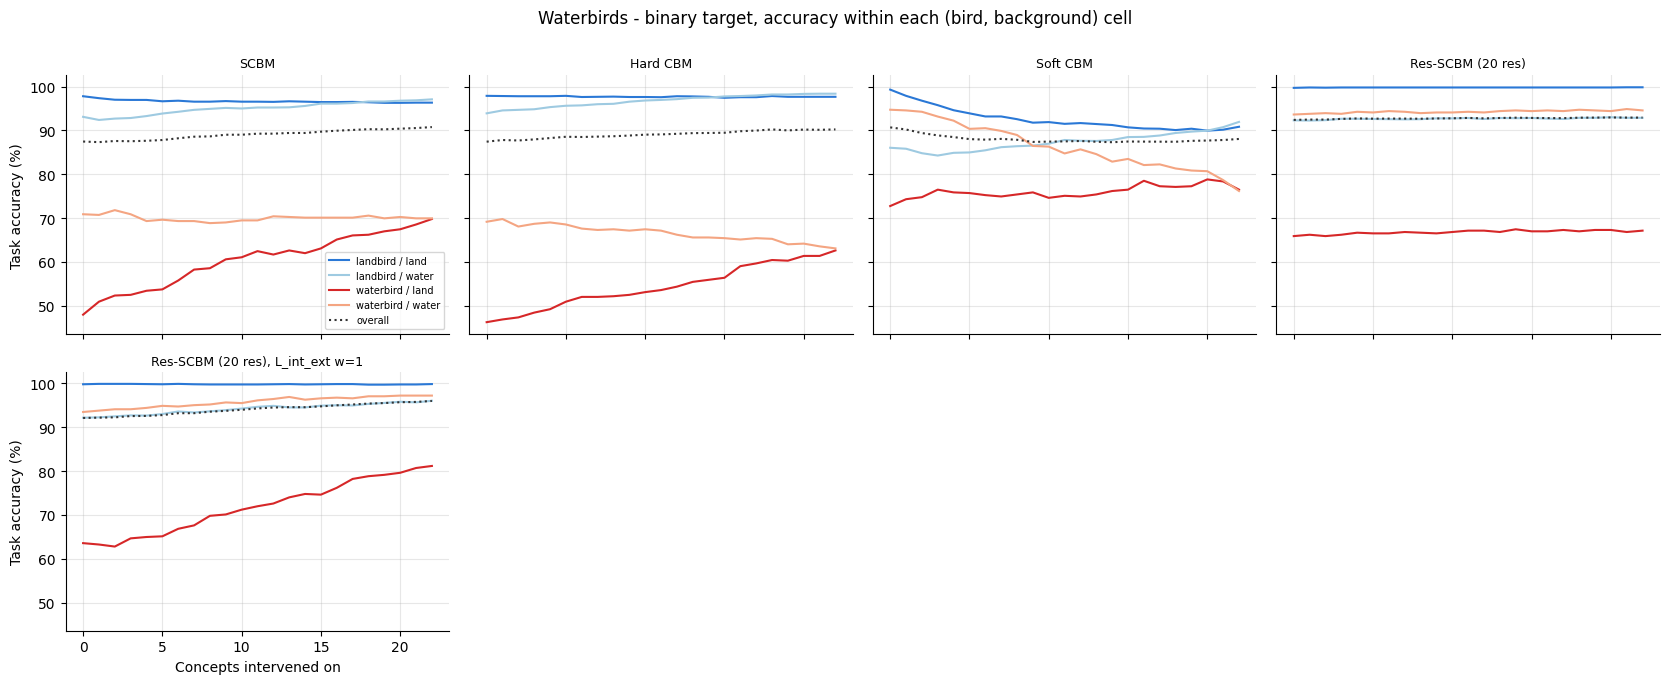

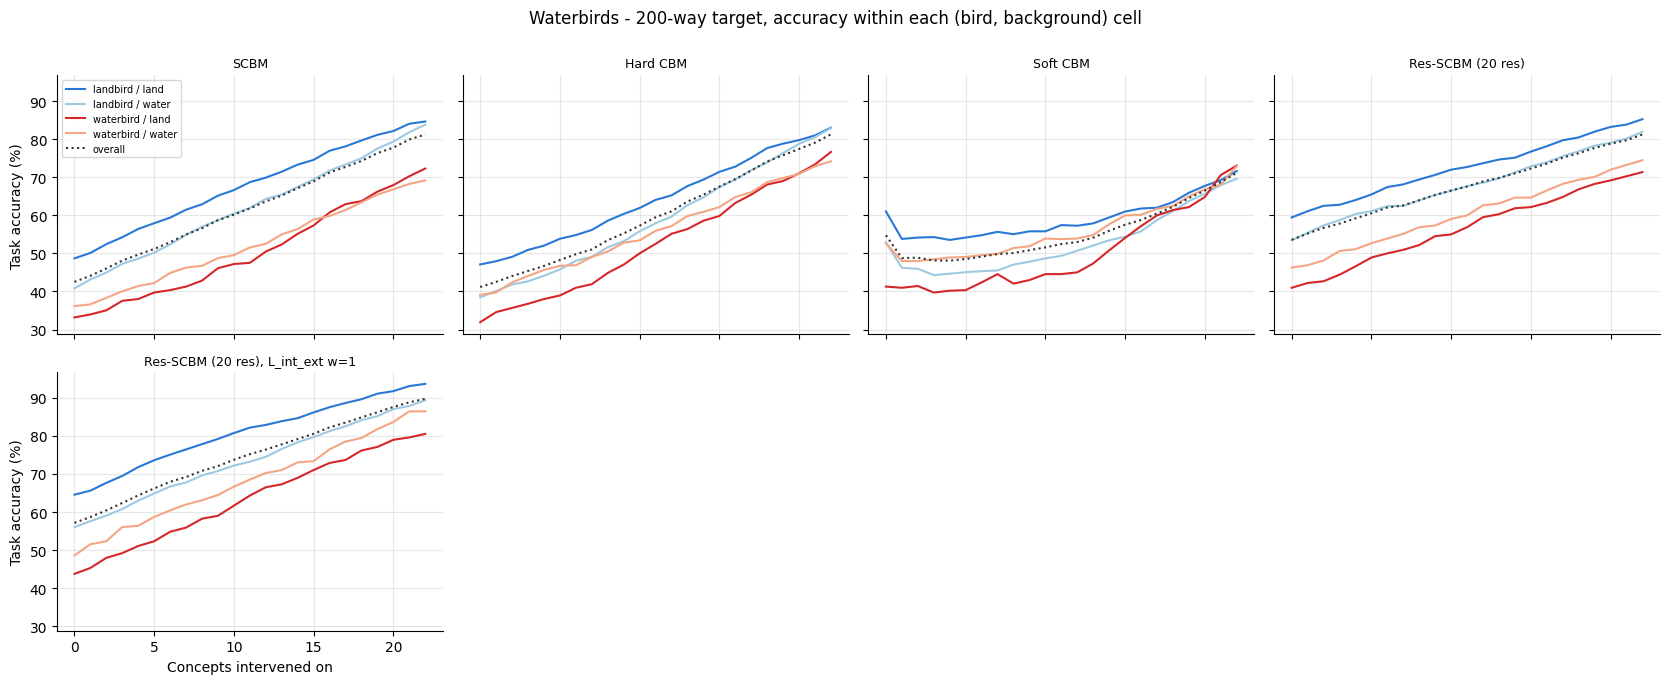

--- concept accuracy per cell at 0 interventions (%) ---


group                                     landbird / land  landbird / water  waterbird / land  waterbird / water  spread
target  label                                                                                                           
200-way Hard CBM                                     92.7              90.5              90.8               93.2     2.8
        Res-SCBM (20 res)                            93.2              92.0              91.1               93.1     2.2
        Res-SCBM (20 res), L_int_ext w=1             93.6              91.7              91.1               93.3     2.4
        SCBM                                         93.0              91.3              90.5               92.9     2.5
        Soft CBM                                     93.3              91.3              90.9               93.2     2.4
binary  Hard CBM                                     92.8              91.2              90.8               92.9     2.1
        Res-SCBM (20 res)                            93.1              92.1              90.9               92.7     2.2
        Res-SCBM (20 res), L_int_ext w=1             92.0              91.2              91.0               93.0     2.0
        SCBM                                         93.2              91.5              91.3               93.3     2.0
        Soft CBM                                     92.4              90.8              91.7               92.9     2.1

In [31]:
# ---- The four cells themselves, per model ----
# Small multiples rather than one panel: 14 runs x 4 cells in one axis is unreadable, and the
# shape *within* a model is the thing being read.
GROUP_COLORS = {"landbird / land": "#2a78d6", "landbird / water": "#9ecae1",
                "waterbird / land": "#d62728", "waterbird / water": "#f4a582"}
for target in ["binary", "200-way"]:
    sub = group_curves[group_curves["target"] == target]
    labels = list(dict.fromkeys(sub["label"]))
    if not labels:
        continue
    ncols = min(4, len(labels))
    nrows = -(-len(labels) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.4 * nrows),
                             squeeze=False, sharex=True, sharey=True)
    for ax, label in zip(axes.ravel(), labels):
        g_all = sub[sub["label"] == label]
        for group, gg in g_all.groupby("group"):
            gg = gg.sort_values("n_intervened")
            ax.plot(gg["n_intervened"], gg["y_acc"], color=GROUP_COLORS[group], label=group)
        summ = y_summary[(y_summary["target"] == target) & (y_summary["label"] == label)].sort_values("n_intervened")
        ax.plot(summ["n_intervened"], summ["overall"], color="0.2", ls=":", label="overall")
        ax.set_title(label, fontsize=9)
        ax.grid(True, alpha=0.3)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
    for ax in axes.ravel()[len(labels):]:
        ax.set_visible(False)
    axes[0, 0].legend(fontsize=7)
    for ax in axes[-1]:
        ax.set_xlabel("Concepts intervened on")
    for ax in axes[:, 0]:
        ax.set_ylabel("Task accuracy (%)")
    fig.suptitle(f"Waterbirds - {target} target, accuracy within each (bird, background) cell", y=1.0)
    fig.tight_layout()
    plt.show()

# ---- Control: is the *concept predictor* background-dependent? ----
# If the four cells' concept accuracy is flat, the background dependence is not in the concept
# channel, and a large task gap has to come from the head (or from the residual).
print("--- concept accuracy per cell at 0 interventions (%) ---")
c0 = group_curves[group_curves["n_intervened"] == 0].pivot_table(
    index=["target", "label"], columns="group", values="c_acc")
c0["spread"] = c0.max(axis=1) - c0.min(axis=1)
display(c0.round(1))

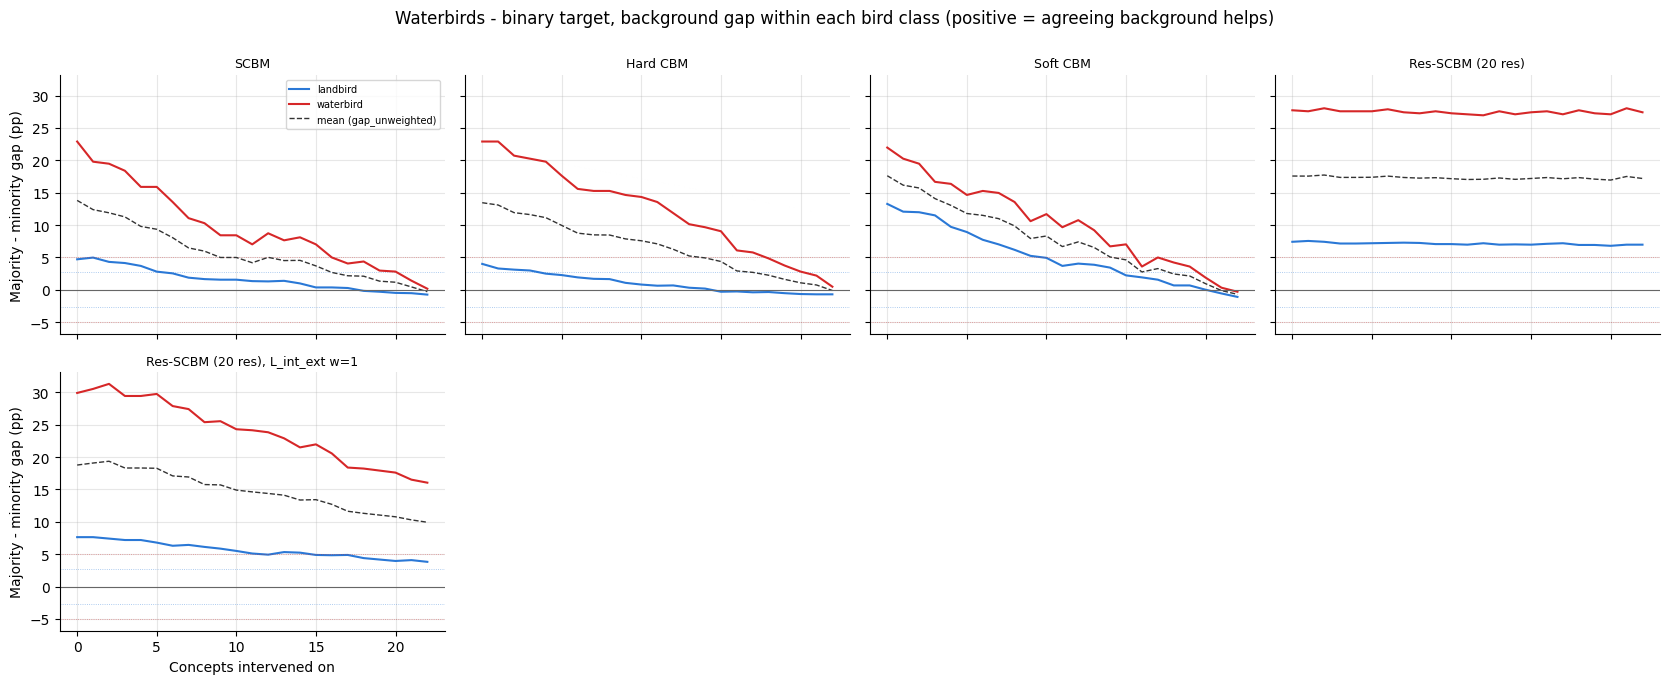

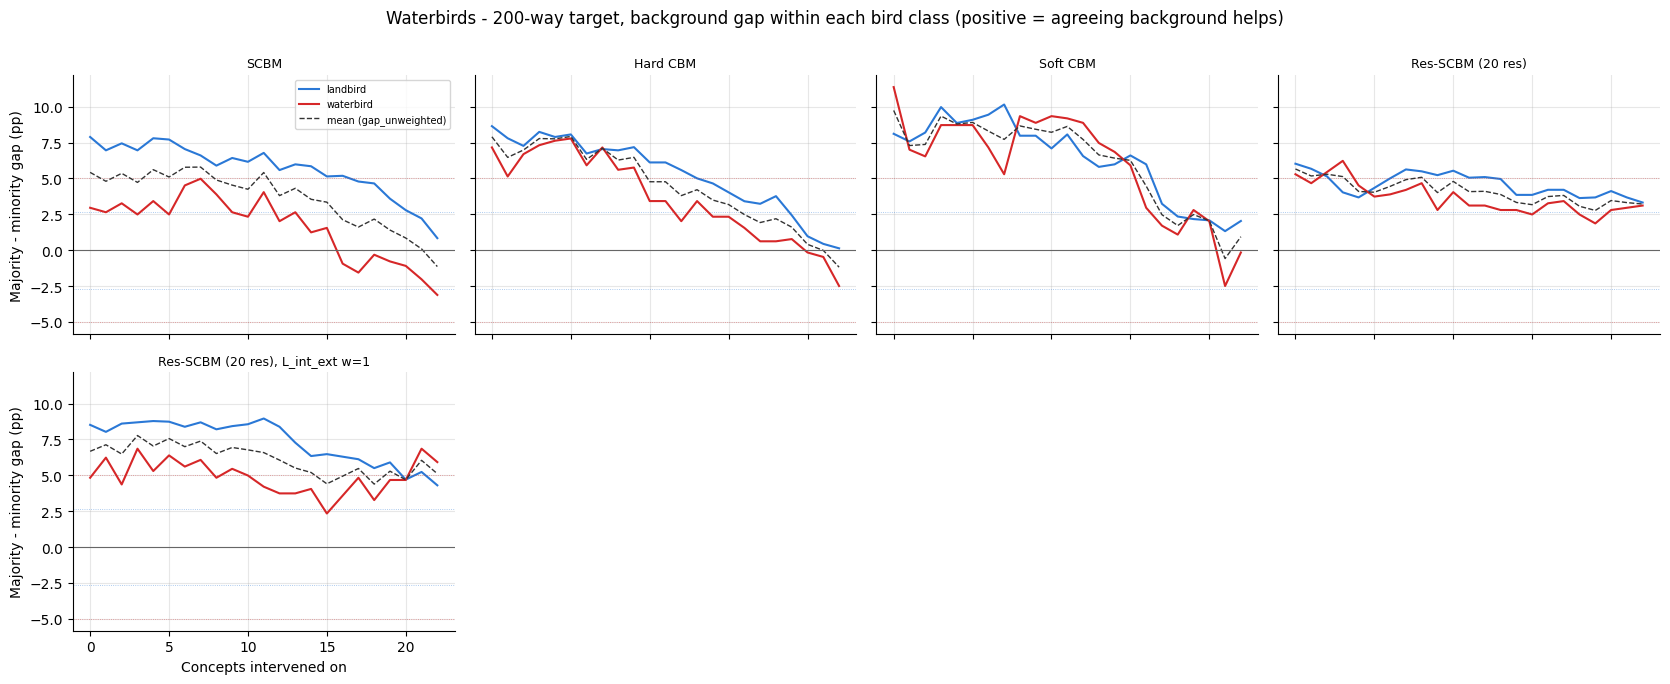

--- background gap (pp), 0 vs full intervention ---


landbird @0  landbird @22  waterbird @0  waterbird @22  mean @0  mean @22
target  label                                                                                                      
200-way Hard CBM                                  8.6           0.1           7.2           -2.5      7.9      -1.2
        Res-SCBM (20 res)                         6.0           3.3           5.3            3.1      5.7       3.2
        Res-SCBM (20 res), L_int_ext w=1          8.5           4.3           4.8            5.9      6.7       5.1
        SCBM                                      7.9           0.8           3.0           -3.1      5.4      -1.1
        Soft CBM                                  8.1           2.0          11.4           -0.2      9.7       0.9
binary  Hard CBM                                  4.0          -0.7          22.9            0.5     13.4      -0.1
        Res-SCBM (20 res)                         7.4           7.0          27.7           27.4     17.6      17.2
        Res-SCBM (20 res), L_int_ext w=1          7.6           3.8          29.9           16.0     18.8       9.9
        SCBM                                      4.7          -0.8          22.9            0.2     13.8      -0.3
        Soft CBM                                 13.3          -1.1          22.0           -0.3     17.6      -0.7

In [32]:
# ---- Majority - minority gap within each bird class ----
# The pairing matters. The contrast has to hold the *bird* fixed and swap the background:
#     landbird   land  - water      (majority - minority)
#     waterbird  water - land       (majority - minority)
# Differencing two cells that share a background instead (landbird/land - waterbird/land) swaps
# the label as well, so it measures the landbird prior -- landbirds are 78% of the test set --
# rather than background reliance, and stays large for a model that ignores the background.
#
# The mean of the two lines is the gap_unweighted already plotted above; they are drawn
# separately because they differ by a factor of three to five. The background is the model's main
# evidence for the rarer waterbird class and near-redundant for landbirds, so an average over the
# two understates the effect exactly where it is worst.
#
# Dotted horizontal lines mark the 95% noise band on each difference (+-2.7pp landbird,
# +-5.0pp waterbird, at cell accuracies of ~0.7): the waterbird cells hold 642 samples each, so a
# gap has to clear ~5pp before it means anything. Several 200-way gaps do not.
PAIRS = {"landbird": ("landbird / land", "landbird / water"),
         "waterbird": ("waterbird / water", "waterbird / land")}
PAIR_COLORS = {"landbird": "#2a78d6", "waterbird": "#d62728"}


def gap_by_class(curve):
    """n_intervened x {landbird, waterbird, mean}: background gap in percentage points."""
    wide = curve.pivot_table(index="n_intervened", columns="group", values="y_acc")
    out = pd.DataFrame({k: wide[maj] - wide[mino] for k, (maj, mino) in PAIRS.items()})
    out["mean"] = out[list(PAIRS)].mean(axis=1)
    return out


# Half-width of the 95% interval on a difference of two independent cell accuracies of ~0.7.
cell_n = group_curves.drop_duplicates("group").set_index("group")["size"]
NOISE = {k: 100 * 1.96 * (0.7 * 0.3 * (1 / cell_n[maj] + 1 / cell_n[mino])) ** 0.5
         for k, (maj, mino) in PAIRS.items()}

for target in ["binary", "200-way"]:
    sub = group_curves[group_curves["target"] == target]
    labels = list(dict.fromkeys(sub["label"]))
    if not labels:
        continue
    ncols = min(4, len(labels))
    nrows = -(-len(labels) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.4 * nrows),
                             squeeze=False, sharex=True, sharey=True)
    for ax, label in zip(axes.ravel(), labels):
        gaps = gap_by_class(sub[sub["label"] == label])
        for k in PAIRS:
            ax.plot(gaps.index, gaps[k], color=PAIR_COLORS[k], label=k)
            for sign in (1, -1):
                ax.axhline(sign * NOISE[k], color=PAIR_COLORS[k], lw=0.6, ls=":", alpha=0.5)
        ax.plot(gaps.index, gaps["mean"], color="0.2", ls="--", lw=1, label="mean (gap_unweighted)")
        ax.axhline(0, color="0.4", lw=0.8)
        ax.set_title(label, fontsize=9)
        ax.grid(True, alpha=0.3)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
    for ax in axes.ravel()[len(labels):]:
        ax.set_visible(False)
    axes[0, 0].legend(fontsize=7)
    for ax in axes[-1]:
        ax.set_xlabel("Concepts intervened on")
    for ax in axes[:, 0]:
        ax.set_ylabel("Majority - minority gap (pp)")
    fig.suptitle(f"Waterbirds - {target} target, background gap within each bird class "
                 f"(positive = agreeing background helps)", y=1.0)
    fig.tight_layout()
    plt.show()

print("--- background gap (pp), 0 vs full intervention ---")
rows = []
for (target, label), g in group_curves.groupby(["target", "label"]):
    gaps = gap_by_class(g)
    lo, hi = gaps.index.min(), gaps.index.max()
    rows.append({"target": target, "label": label,
                 **{f"{k} @{n}": gaps.loc[n, k] for k in list(PAIRS) + ["mean"] for n in (lo, hi)}})
display(pd.DataFrame(rows).set_index(["target", "label"]).round(1))

## Analysis